# 19 - Splits with DataLoaders

**Section:** Cross Validation | **Prereqs:** `Cross Validation/CrossValidation.ipynb` | **Next:** `Regularization/Regularization_theory.ipynb`

The same split, done the way every later notebook does it: split first, wrap
each half in its own `TensorDataset`, then give each its own `DataLoader`.

**Why two loaders**
- The train loader shuffles and batches: `shuffle=True`, `batch_size=10`.
- The test loader takes the whole split as one batch and never shuffles. Order
  is irrelevant when you are not computing gradients.

**Split before you batch.** Splitting a DataLoader is awkward; splitting arrays
and building two loaders is trivial. The order also protects against the classic
leak of normalising over the full dataset and only splitting afterwards.

**Also fixed here:** per-epoch loss is the mean over batches, not whatever the
last batch happened to score. Recording `losses[epoch] = loss` inside the batch
loop is a bookkeeping bug that produces a plausible-looking but wrong curve.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
iris = load_iris()
data = pd.DataFrame(iris.data , columns=iris.feature_names)
target = iris.target

In [ ]:
# 80/20 split on the raw arrays, before any tensor or loader exists.
data_train, data_test, target_train, target_test = train_test_split(data,target,test_size=0.2)
data_train.shape

(120, 4)

In [ ]:
# Each split becomes its own TensorDataset. Features float32, labels long.
data_train = TensorDataset(torch.tensor(data_train.to_numpy(),dtype=torch.float),torch.tensor(target_train,dtype=torch.long))

data_test = TensorDataset(torch.tensor(data_test.to_numpy(),dtype=torch.float), torch.tensor(target_test,dtype=torch.long))

In [ ]:
# Train loader: shuffled, batches of 10, so ~12 gradient updates per epoch.
# Test loader: a single batch holding all 30 test samples.
train_loader = DataLoader(data_train, shuffle=True, batch_size=10,)
test_loader = DataLoader(data_test, batch_size=data_test.tensors[0].shape[0])

In [ ]:
# Iterating the train loader yields (x, y) batch pairs. Re-run it and the
# composition changes - that is shuffle=True at work.
for i,j in train_loader:
  print(i,j)
  print()

tensor([[4.9000, 2.4000, 3.3000, 1.0000],
        [6.9000, 3.1000, 5.1000, 2.3000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.5000, 2.4000, 3.7000, 1.0000],
        [5.5000, 2.3000, 4.0000, 1.3000],
        [7.7000, 3.0000, 6.1000, 2.3000],
        [5.1000, 3.4000, 1.5000, 0.2000],
        [5.1000, 2.5000, 3.0000, 1.1000],
        [5.0000, 3.3000, 1.4000, 0.2000],
        [6.3000, 2.5000, 4.9000, 1.5000]]) tensor([1, 2, 0, 1, 1, 2, 0, 1, 0, 1])

tensor([[6.0000, 2.7000, 5.1000, 1.6000],
        [6.6000, 3.0000, 4.4000, 1.4000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [5.0000, 2.3000, 3.3000, 1.0000],
        [5.8000, 2.7000, 5.1000, 1.9000],
        [6.7000, 3.3000, 5.7000, 2.5000],
        [6.0000, 2.9000, 4.5000, 1.5000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [5.8000, 2.7000, 3.9000, 1.2000],
        [6.1000, 3.0000, 4.9000, 1.8000]]) tensor([1, 1, 0, 1, 2, 2, 1, 0, 1, 2])

tensor([[5.2000, 3.5000, 1.5000, 0.2000],
        [6.3000, 3.3000, 6.0000, 2.5

In [ ]:
# The test loader yields exactly one batch, the whole split.
for i,j in test_loader:
  print(i,j)

tensor([[5.6000, 2.8000, 4.9000, 2.0000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [6.1000, 3.0000, 4.6000, 1.4000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [6.5000, 3.0000, 5.8000, 2.2000],
        [7.2000, 3.2000, 6.0000, 1.8000],
        [6.5000, 3.0000, 5.5000, 1.8000],
        [6.7000, 3.0000, 5.2000, 2.3000],
        [7.2000, 3.6000, 6.1000, 2.5000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [6.4000, 2.9000, 4.3000, 1.3000],
        [6.1000, 2.9000, 4.7000, 1.4000],
        [7.4000, 2.8000, 6.1000, 1.9000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [5.6000, 2.9000, 3.6000, 1.3000],
        [6.4000, 2.8000, 5.6000, 2.1000],
        [7.7000, 2.8000, 6.7000, 2.0000],
        [5.1000, 3.5000, 1.4000, 0.2000],
        [6.4000, 2.8000, 5.6000, 2.2000],
        [5.6000, 3.0000, 4.1000, 1.3000],
        [6.1000, 2.8000, 4.7000, 1.2000],
        [6.4000, 3.2000, 4.5000, 1

In [ ]:
# Same model as before, but with the layers wrapped in an nn.Sequential
# attribute - a common hybrid: Sequential for a straight run of layers, Module
# for anything the forward pass has to decide.
class model(nn.Module):
  def __init__(self):
   super().__init__()

   self.layers = nn.Sequential(
       nn.Linear(4,24),
       nn.ReLU(),
       nn.Linear(24,24),
       nn.ReLU(),
       nn.Linear(24,24),
       nn.ReLU(),
       nn.Linear(24,3)
   )


  def forward(self,x):
    return self.layers(x)

In [ ]:
Classifier = model()
lr = 0.01
epochs = 500
optimizer = torch.optim.SGD(Classifier.parameters(), lr = lr)

lossFunc = nn.CrossEntropyLoss()

In [ ]:
# Mini-batch training: the inner loop now runs one update per BATCH, so an
# epoch performs many updates instead of one.
# Loss and accuracy are collected per batch and AVERAGED per epoch. Assigning
# losses[epoch] inside the batch loop instead would silently record only the
# last batch - a common and invisible bookkeeping bug.
train_accuracy = []
test_accuracy = []
losses = torch.zeros(epochs)

for epoch in range(epochs):
  batch_accuracy = []
  batch_loss = []

  for x,y in train_loader:

    yhat = Classifier.forward(x)

    loss = lossFunc(yhat,y)
    batch_loss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_accuracy.append(100 * torch.mean((torch.argmax(yhat, dim=1) == y).float()).item())



  X,y = next(iter(test_loader))
  losses[epoch] = np.mean(batch_loss)
  train_accuracy.append(np.mean(batch_accuracy))
  test_accuracy.append(100 * torch.mean( (torch.argmax(Classifier(X),dim=1) == y).float()).item())

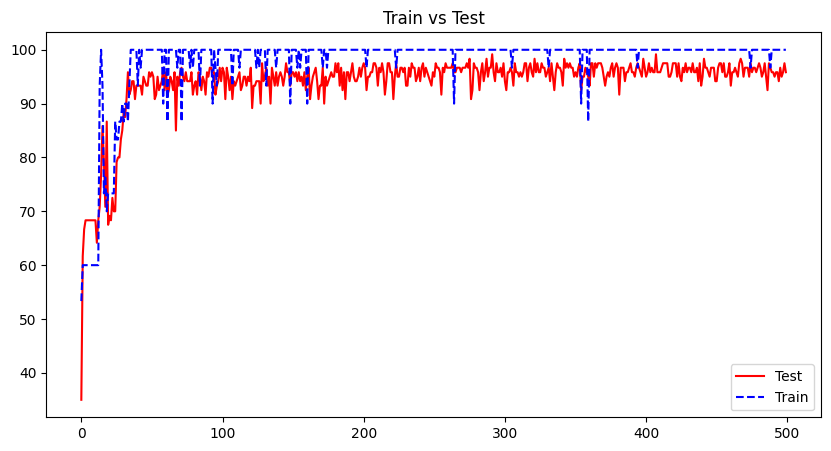

In [ ]:
# Train vs test accuracy. The gap between the two lines is overfitting.
plt.figure(figsize=(10,5))
plt.plot(train_accuracy, "r-", label= "Train")
plt.plot(test_accuracy, "b--", label= "Test")
plt.legend();
plt.title("Train vs Test");

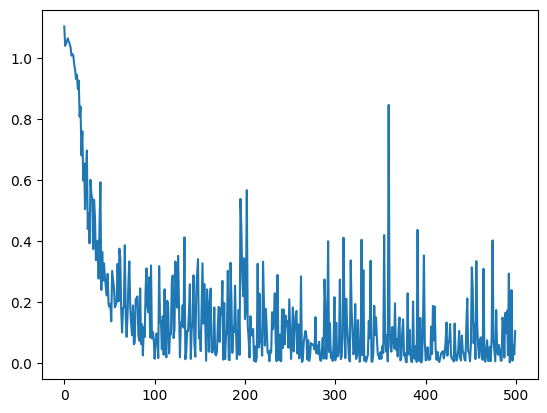

In [ ]:
# The loss trace - noisier than a full-batch version, because each epoch's
# gradient estimates come from small samples. That noise is not a defect; it
# helps the optimizer escape sharp minima.
plt.plot(losses.detach());